<a href="https://colab.research.google.com/github/allasyva-source/ukraine-air-raid-alerts-time-series/blob/main/01_time_series_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Analysis of Recorded Air-Raid Alert Starts in Ukraine

## Research question

How did the daily number of recorded oblast-level air-raid alert starts in Ukraine change over time in the available historical dataset?

## Scope

This notebook presents a descriptive analysis of historical, aggregated records only.

It does not forecast future alerts, provide real-time monitoring, estimate danger, or explain military causes of changes in the data.

## Data source

The analysis uses the volunteer oblast-level dataset from the public GitHub repository:

`Vadimkin/ukrainian-air-raid-sirens-dataset`

The original timestamps are recorded in UTC. For daily and monthly analysis, timestamps are converted to the `Europe/Kyiv` time zone.

## Unit of analysis

Each row represents a recorded alert start associated with an oblast-level location.

The analysis counts recorded dataset entries. These counts should not be interpreted as the number of attacks, casualties, incidents, or direct measures of danger.


## 1. Data loading

In [1]:
import pandas as pd

DATA_URL = (
    "https://raw.githubusercontent.com/Vadimkin/"
    "ukrainian-air-raid-sirens-dataset/main/"
    "datasets/volunteer_data_en.csv"
)

df = pd.read_csv(DATA_URL)

print("Дані успішно завантажено")
print("Розмір таблиці:", df.shape)

Дані успішно завантажено
Розмір таблиці: (101705, 4)


## 2. Initial data quality checks

In [2]:
print("Перші 5 рядків таблиці:")
display(df.head())

print("\nНазви колонок:")
print(df.columns.tolist())

print("\nТип даних у кожній колонці:")
print(df.dtypes)

Перші 5 рядків таблиці:


,region,started_at,finished_at,naive
0,Kyiv City,2022-02-25 16:36:22+00:00,2022-02-25 17:06:22+00:00,True
1,Cherkaska oblast,2022-02-25 18:36:21+00:00,2022-02-25 19:32:11+00:00,False
2,Rivnenska oblast,2022-02-25 18:56:44+00:00,2022-02-25 19:26:44+00:00,True
3,Zaporizka oblast,2022-02-25 18:57:51+00:00,2022-02-25 19:27:51+00:00,True
4,Volynska oblast,2022-02-25 19:41:57+00:00,2022-02-26 04:01:55+00:00,False



Назви колонок:
['region', 'started_at', 'finished_at', 'naive']

Тип даних у кожній колонці:
region         object
started_at     object
finished_at    object
naive            bool
dtype: object


In [3]:
missing_values = df.isna().sum()

print("Кількість пропусків у кожній колонці:")
display(missing_values.to_frame(name="missing_values"))

Кількість пропусків у кожній колонці:


,missing_values
region,0
started_at,0
finished_at,0
naive,0


In [4]:
started = pd.to_datetime(df["started_at"], utc=True, errors="coerce")
finished = pd.to_datetime(df["finished_at"], utc=True, errors="coerce")

print("Некоректні значення у started_at:", started.isna().sum())
print("Некоректні значення у finished_at:", finished.isna().sum())

print("\nНайраніший запис:", started.min())
print("Найпізніший запис:", started.max())

print("\nЗаписів, де завершення раніше за початок:")
print((finished < started).sum())

Некоректні значення у started_at: 0
Некоректні значення у finished_at: 0

Найраніший запис: 2022-02-25 16:36:22+00:00
Найпізніший запис: 2026-06-23 00:38:32+00:00

Записів, де завершення раніше за початок:
0


In [5]:
duplicate_count = df.duplicated().sum()

print("Кількість повністю однакових рядків:", duplicate_count)

Кількість повністю однакових рядків: 0


## 3. Daily time series construction

In [6]:
# Створюємо окрему робочу копію, не змінюючи оригінальну таблицю df
events = df.copy()

# Перетворюємо текстовий час початку на формат дата-час
events["started_at"] = pd.to_datetime(
    events["started_at"],
    utc=True
)

# Беремо лише дату: рік, місяць, день
events["date_utc"] = events["started_at"].dt.normalize()

# Не включаємо поточний незавершений день
today_utc = pd.Timestamp.now(tz="UTC").normalize()
events_complete = events[events["date_utc"] < today_utc].copy()

# Рахуємо кількість записів у кожен день
daily_counts = (
    events_complete
    .groupby("date_utc")
    .size()
    .reset_index(name="alert_starts")
)

print("Перші 10 днів у новій таблиці:")
display(daily_counts.head(10))

print("\nКількість днів у часовому ряді:", len(daily_counts))
print("Період:", daily_counts["date_utc"].min(), "—", daily_counts["date_utc"].max())

Перші 10 днів у новій таблиці:


,date_utc,alert_starts
0,2022-02-25 00:00:00+00:00,7
1,2022-02-26 00:00:00+00:00,42
2,2022-02-27 00:00:00+00:00,69
3,2022-02-28 00:00:00+00:00,69
4,2022-03-01 00:00:00+00:00,92
5,2022-03-02 00:00:00+00:00,89
6,2022-03-03 00:00:00+00:00,58
7,2022-03-04 00:00:00+00:00,67
8,2022-03-05 00:00:00+00:00,56
9,2022-03-06 00:00:00+00:00,65



Кількість днів у часовому ряді: 1579
Період: 2022-02-25 00:00:00+00:00 — 2026-06-22 00:00:00+00:00


In [7]:
events = df.copy()

# Читаємо час як UTC
events["started_at"] = pd.to_datetime(
    events["started_at"],
    utc=True
)

# Переводимо час у часову зону України
events["started_at_kyiv"] = events["started_at"].dt.tz_convert("Europe/Kyiv")

# Беремо лише дату за київським календарем
events["date_kyiv"] = events["started_at_kyiv"].dt.normalize()

# Не включаємо сьогоднішній незавершений день за київським часом
today_kyiv = pd.Timestamp.now(tz="Europe/Kyiv").normalize()
events_complete = events[events["date_kyiv"] < today_kyiv].copy()

# Рахуємо кількість стартів у кожен день
daily_counts_kyiv = (
    events_complete
    .groupby("date_kyiv")
    .size()
    .reset_index(name="alert_starts")
)

print("Перші 10 днів за київським часом:")
display(daily_counts_kyiv.head(10))

print("\nКількість днів:", len(daily_counts_kyiv))
print(
    "Період:",
    daily_counts_kyiv["date_kyiv"].min(),
    "—",
    daily_counts_kyiv["date_kyiv"].max()
)

Перші 10 днів за київським часом:


,date_kyiv,alert_starts
0,2022-02-25 00:00:00+02:00,6
1,2022-02-26 00:00:00+02:00,42
2,2022-02-27 00:00:00+02:00,65
3,2022-02-28 00:00:00+02:00,73
4,2022-03-01 00:00:00+02:00,91
5,2022-03-02 00:00:00+02:00,79
6,2022-03-03 00:00:00+02:00,69
7,2022-03-04 00:00:00+02:00,64
8,2022-03-05 00:00:00+02:00,57
9,2022-03-06 00:00:00+02:00,64



Кількість днів: 1579
Період: 2022-02-25 00:00:00+02:00 — 2026-06-22 00:00:00+03:00


## 4. Visual exploration and aggregation

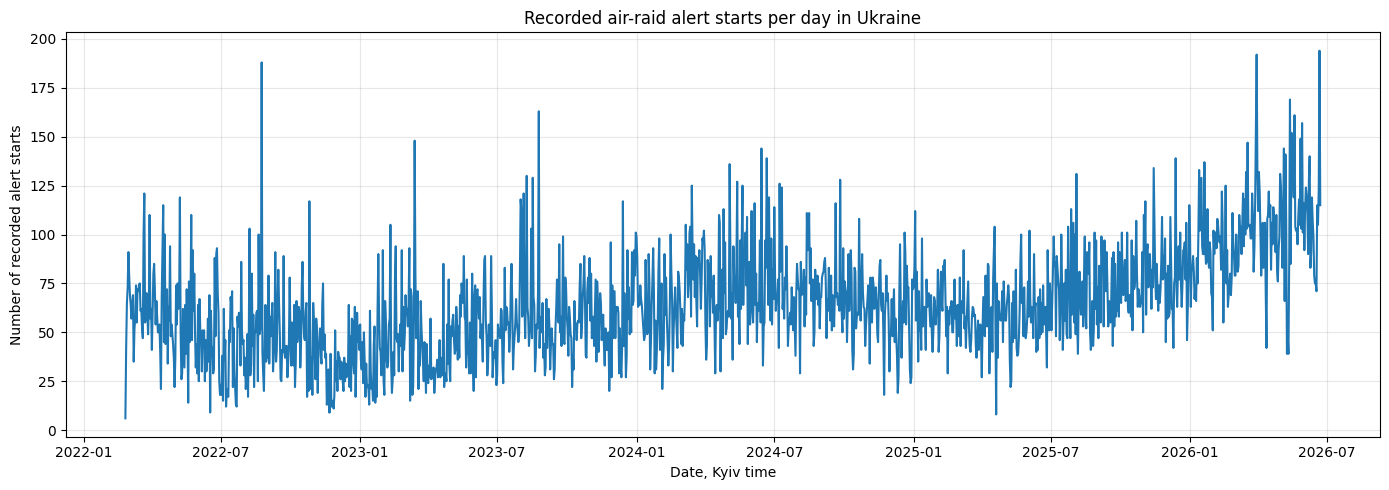

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    daily_counts_kyiv["date_kyiv"],
    daily_counts_kyiv["alert_starts"]
)

plt.title("Recorded air-raid alert starts per day in Ukraine")
plt.xlabel("Date, Kyiv time")
plt.ylabel("Number of recorded alert starts")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

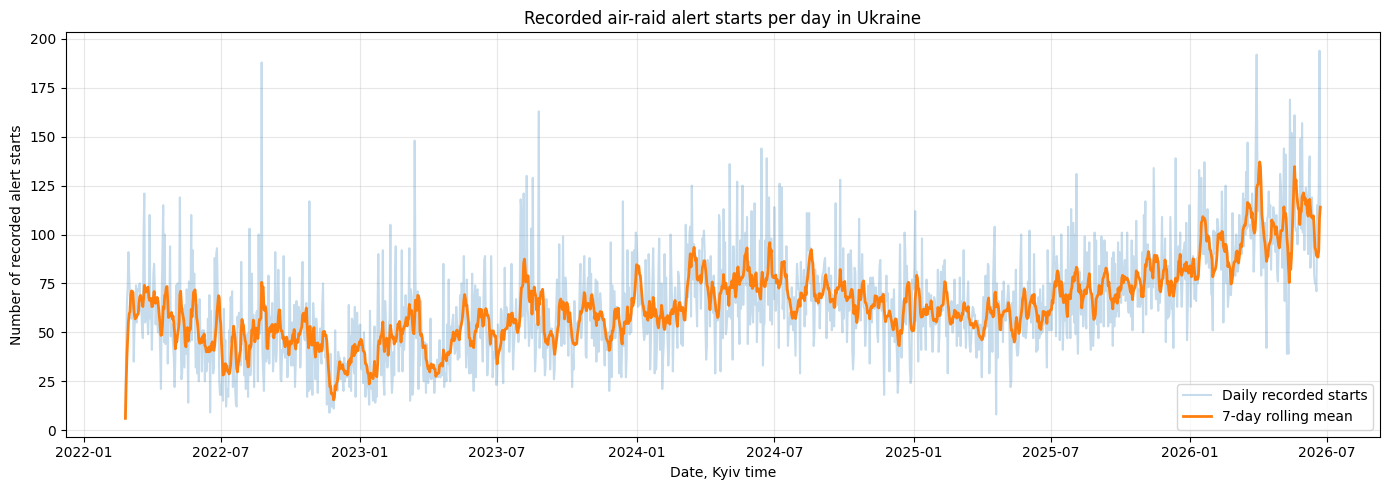

In [9]:
# Додаємо 7-денне ковзне середнє
daily_counts_kyiv["rolling_mean_7d"] = (
    daily_counts_kyiv["alert_starts"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# Будуємо графік: щоденні значення + згладжена лінія
plt.figure(figsize=(14, 5))

plt.plot(
    daily_counts_kyiv["date_kyiv"],
    daily_counts_kyiv["alert_starts"],
    alpha=0.25,
    label="Daily recorded starts"
)

plt.plot(
    daily_counts_kyiv["date_kyiv"],
    daily_counts_kyiv["rolling_mean_7d"],
    linewidth=2,
    label="7-day rolling mean"
)

plt.title("Recorded air-raid alert starts per day in Ukraine")
plt.xlabel("Date, Kyiv time")
plt.ylabel("Number of recorded alert starts")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
summary_stats = pd.DataFrame({
    "metric": [
        "Number of days",
        "Average starts per day",
        "Median starts per day",
        "Minimum starts in one day",
        "Maximum starts in one day"
    ],
    "value": [
        len(daily_counts_kyiv),
        daily_counts_kyiv["alert_starts"].mean(),
        daily_counts_kyiv["alert_starts"].median(),
        daily_counts_kyiv["alert_starts"].min(),
        daily_counts_kyiv["alert_starts"].max()
    ]
})

summary_stats["value"] = summary_stats["value"].round(2)

display(summary_stats)

,metric,value
0,Number of days,1579.0
1,Average starts per day,64.4
2,Median starts per day,62.0
3,Minimum starts in one day,6.0
4,Maximum starts in one day,194.0


In [11]:
# Беремо лише повні календарні місяці
current_month_start = pd.Timestamp.now(
    tz="Europe/Kyiv"
).normalize().replace(day=1)

full_months = daily_counts_kyiv[
    daily_counts_kyiv["date_kyiv"] < current_month_start
].copy()

# Додаємо позначку місяця для кожного дня
full_months["month"] = (
    full_months["date_kyiv"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

# Підсумовуємо кількість стартів у кожному місяці
monthly_counts = (
    full_months
    .groupby("month")["alert_starts"]
    .sum()
    .reset_index()
)

# Робимо місяць зручним для графіків і таблиць
monthly_counts["month"] = monthly_counts["month"].astype(str)

print("Перші 10 місяців:")
display(monthly_counts.head(10))

print("\nОстанні 10 повних місяців:")
display(monthly_counts.tail(10))

Перші 10 місяців:


,month,alert_starts
0,2022-02,186
1,2022-03,2084
2,2022-04,1792
3,2022-05,1720
4,2022-06,1439
5,2022-07,1240
6,2022-08,1580
7,2022-09,1493
8,2022-10,1524
9,2022-11,1028



Останні 10 повних місяців:


,month,alert_starts
42,2025-08,2154
43,2025-09,2168
44,2025-10,2291
45,2025-11,2505
46,2025-12,2464
47,2026-01,2784
48,2026-02,2558
49,2026-03,3343
50,2026-04,3001
51,2026-05,3402


In [12]:
analysis_start = pd.Timestamp("2022-03-01", tz="Europe/Kyiv")

current_month_start = pd.Timestamp.now(
    tz="Europe/Kyiv"
).normalize().replace(day=1)

full_months = daily_counts_kyiv[
    (daily_counts_kyiv["date_kyiv"] >= analysis_start)
    & (daily_counts_kyiv["date_kyiv"] < current_month_start)
].copy()

full_months["month"] = (
    full_months["date_kyiv"]
    .dt.tz_localize(None)
    .dt.to_period("M")
)

monthly_counts = (
    full_months
    .groupby("month")["alert_starts"]
    .sum()
    .reset_index()
)

monthly_counts["month"] = monthly_counts["month"].astype(str)

print("Перші 5 повних місяців:")
display(monthly_counts.head())

print("\nОстанні 5 повних місяців:")
display(monthly_counts.tail())

Перші 5 повних місяців:


,month,alert_starts
0,2022-03,2084
1,2022-04,1792
2,2022-05,1720
3,2022-06,1439
4,2022-07,1240



Останні 5 повних місяців:


,month,alert_starts
46,2026-01,2784
47,2026-02,2558
48,2026-03,3343
49,2026-04,3001
50,2026-05,3402


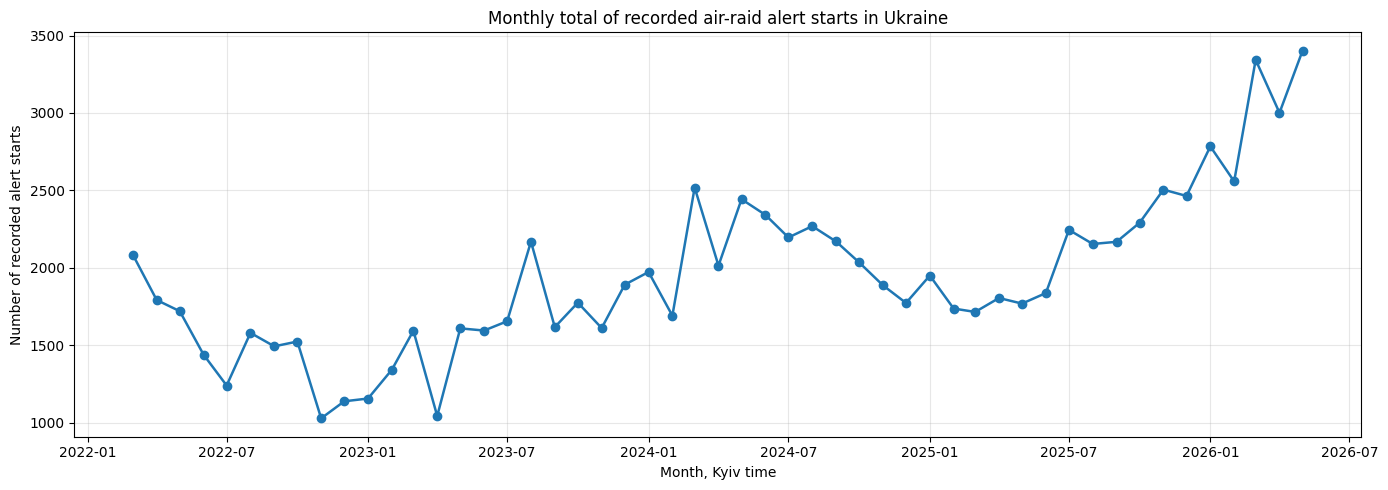

In [13]:
# Перетворюємо назву місяця на дату для зручного графіка
monthly_counts["month_date"] = pd.to_datetime(
    monthly_counts["month"] + "-01"
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_counts["month_date"],
    monthly_counts["alert_starts"],
    marker="o",
    linewidth=1.8
)

plt.title("Monthly total of recorded air-raid alert starts in Ukraine")
plt.xlabel("Month, Kyiv time")
plt.ylabel("Number of recorded alert starts")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
monthly_daily_average = (
    full_months
    .groupby("month")["alert_starts"]
    .agg(
        monthly_total="sum",
        days_in_month="count",
        average_starts_per_day="mean"
    )
    .reset_index()
)

monthly_daily_average["month"] = (
    monthly_daily_average["month"]
    .astype(str)
)

monthly_daily_average["average_starts_per_day"] = (
    monthly_daily_average["average_starts_per_day"]
    .round(2)
)

print("Перші 5 повних місяців:")
display(monthly_daily_average.head())

print("\nОстанні 5 повних місяців:")
display(monthly_daily_average.tail())

Перші 5 повних місяців:


,month,monthly_total,days_in_month,average_starts_per_day
0,2022-03,2084,31,67.23
1,2022-04,1792,30,59.73
2,2022-05,1720,31,55.48
3,2022-06,1439,30,47.97
4,2022-07,1240,31,40.00



Останні 5 повних місяців:


,month,monthly_total,days_in_month,average_starts_per_day
46,2026-01,2784,31,89.81
47,2026-02,2558,28,91.36
48,2026-03,3343,31,107.84
49,2026-04,3001,30,100.03
50,2026-05,3402,31,109.74


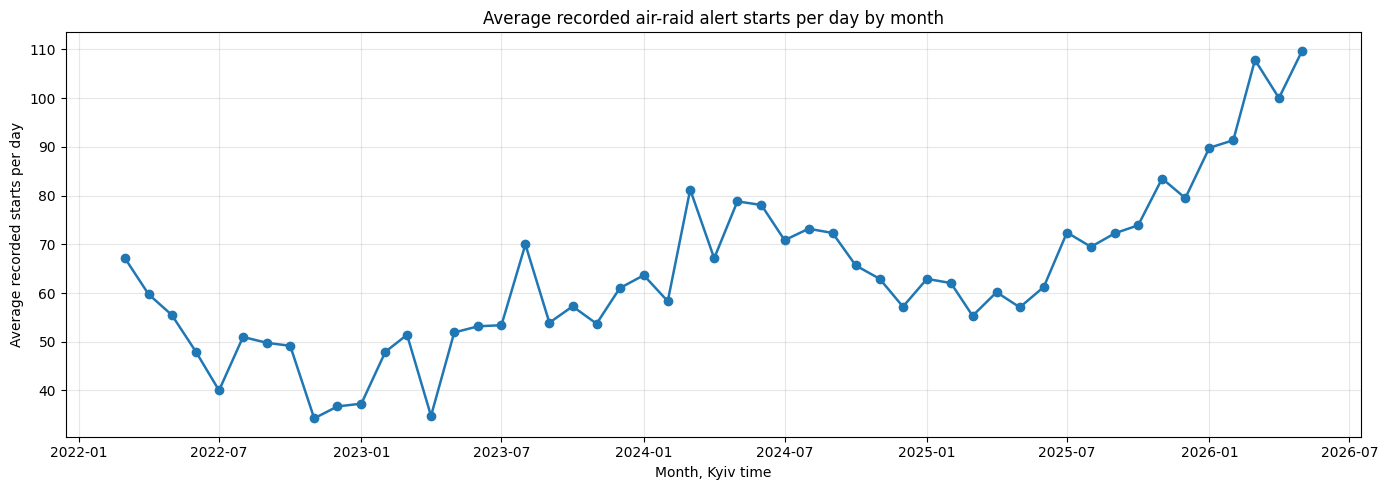

In [15]:
monthly_daily_average["month_date"] = pd.to_datetime(
    monthly_daily_average["month"] + "-01"
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_daily_average["month_date"],
    monthly_daily_average["average_starts_per_day"],
    marker="o",
    linewidth=1.8
)

plt.title("Average recorded air-raid alert starts per day by month")
plt.xlabel("Month, Kyiv time")
plt.ylabel("Average recorded starts per day")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

weekday_summary = (
    daily_counts_kyiv
    .assign(
        weekday=daily_counts_kyiv["date_kyiv"].dt.day_name()
    )
    .groupby("weekday")["alert_starts"]
    .agg(
        days_observed="size",
        average_starts_per_day="mean",
        median_starts_per_day="median"
    )
    .reindex(weekday_order)
    .reset_index()
)

weekday_summary["average_starts_per_day"] = (
    weekday_summary["average_starts_per_day"].round(2)
)

weekday_summary["median_starts_per_day"] = (
    weekday_summary["median_starts_per_day"].round(2)
)

display(weekday_summary)

,weekday,days_observed,average_starts_per_day,median_starts_per_day
0,Monday,226,64.71,63.0
1,Tuesday,225,65.01,62.0
2,Wednesday,225,66.06,64.0
3,Thursday,225,67.12,64.0
4,Friday,226,66.41,63.0
5,Saturday,226,62.98,60.5
6,Sunday,226,58.54,56.0


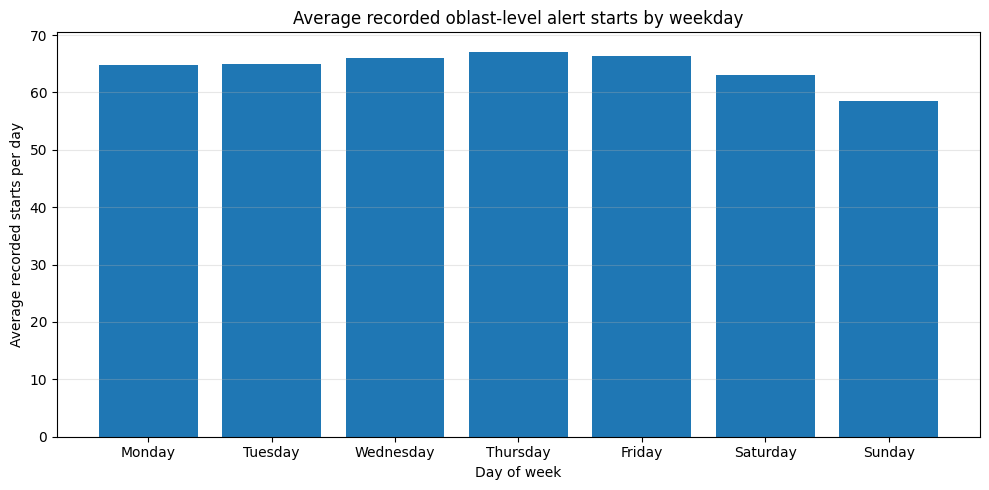

In [17]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_summary["weekday"],
    weekday_summary["average_starts_per_day"]
)

plt.title("Average recorded oblast-level alert starts by weekday")
plt.xlabel("Day of week")
plt.ylabel("Average recorded starts per day")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

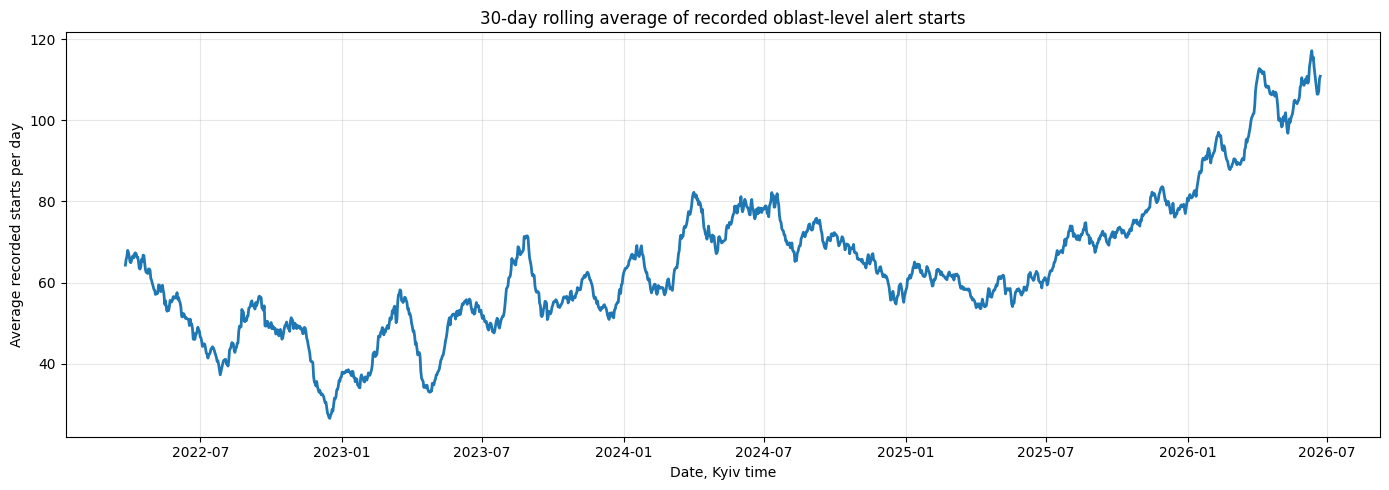

In [18]:
daily_counts_kyiv["rolling_mean_30d"] = (
    daily_counts_kyiv["alert_starts"]
    .rolling(window=30, min_periods=30)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_counts_kyiv["date_kyiv"],
    daily_counts_kyiv["rolling_mean_30d"],
    linewidth=2
)

plt.title("30-day rolling average of recorded oblast-level alert starts")
plt.xlabel("Date, Kyiv time")
plt.ylabel("Average recorded starts per day")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
expected_dates = pd.date_range(
    start=daily_counts_kyiv["date_kyiv"].min(),
    end=daily_counts_kyiv["date_kyiv"].max(),
    freq="D",
    tz="Europe/Kyiv"
)

observed_dates = pd.DatetimeIndex(daily_counts_kyiv["date_kyiv"])

missing_dates = expected_dates.difference(observed_dates)

print("Очікувана кількість календарних дат:", len(expected_dates))
print("Кількість дат у часовому ряді:", len(observed_dates))
print("Пропущені календарні дати:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nПерші пропущені дати:")
    print(missing_dates[:10])
else:
    print("\nПропущених дат немає.")

Очікувана кількість календарних дат: 1579
Кількість дат у часовому ряді: 1579
Пропущені календарні дати: 0

Пропущених дат немає.


In [20]:
analysis_years = [2023, 2024, 2025]

yearly_data = daily_counts_kyiv[
    daily_counts_kyiv["date_kyiv"].dt.year.isin(analysis_years)
].copy()

yearly_summary = (
    yearly_data
    .assign(year=yearly_data["date_kyiv"].dt.year)
    .groupby("year")["alert_starts"]
    .agg(
        days_observed="count",
        total_alert_starts="sum",
        average_starts_per_day="mean",
        median_starts_per_day="median"
    )
    .reset_index()
)

yearly_summary["expected_days"] = yearly_summary["year"].map({
    2023: 365,
    2024: 366,
    2025: 365
})

yearly_summary["all_days_present"] = (
    yearly_summary["days_observed"]
    == yearly_summary["expected_days"]
)

yearly_summary["average_starts_per_day"] = (
    yearly_summary["average_starts_per_day"].round(2)
)

yearly_summary["median_starts_per_day"] = (
    yearly_summary["median_starts_per_day"].round(2)
)

display(yearly_summary)

,year,days_observed,total_alert_starts,average_starts_per_day,median_starts_per_day,expected_days,all_days_present
0,2023,365,19057,52.21,50.0,365,True
1,2024,366,25311,69.16,68.0,366,True
2,2025,365,24640,67.51,65.0,365,True


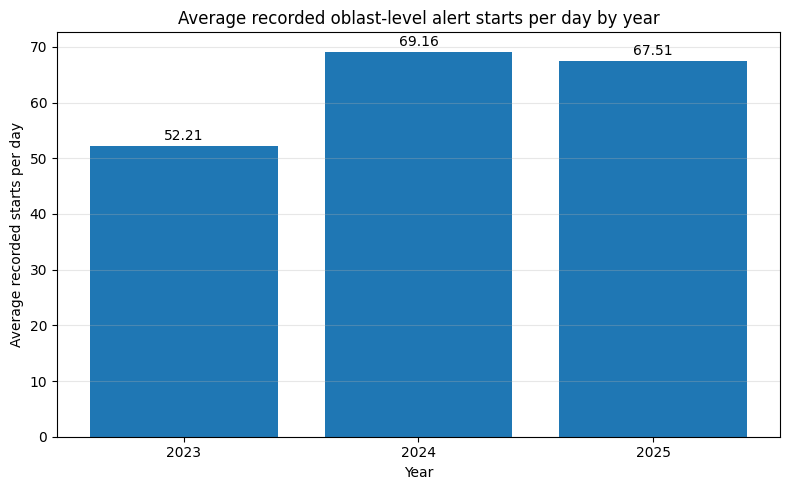

In [21]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    yearly_summary["year"].astype(str),
    yearly_summary["average_starts_per_day"]
)

plt.title("Average recorded oblast-level alert starts per day by year")
plt.xlabel("Year")
plt.ylabel("Average recorded starts per day")

for bar, value in zip(bars, yearly_summary["average_starts_per_day"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

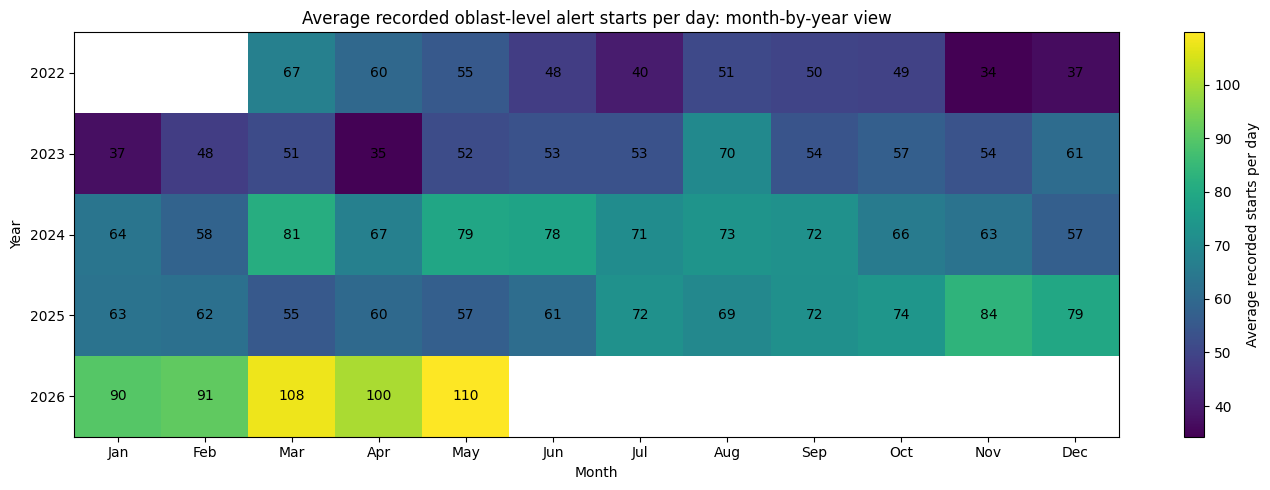

In [22]:
import numpy as np

calendar_data = monthly_daily_average.copy()

calendar_data["month_date"] = pd.to_datetime(
    calendar_data["month"] + "-01"
)

calendar_data["year"] = calendar_data["month_date"].dt.year
calendar_data["month_number"] = calendar_data["month_date"].dt.month

heatmap_table = calendar_data.pivot(
    index="year",
    columns="month_number",
    values="average_starts_per_day"
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

fig, ax = plt.subplots(figsize=(14, 5))

image = ax.imshow(
    np.ma.masked_invalid(heatmap_table.to_numpy()),
    aspect="auto"
)

ax.set_title(
    "Average recorded oblast-level alert starts per day: month-by-year view"
)
ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

ax.set_yticks(range(len(heatmap_table.index)))
ax.set_yticklabels(heatmap_table.index)

for row_index, year in enumerate(heatmap_table.index):
    for column_index, month in enumerate(heatmap_table.columns):
        value = heatmap_table.loc[year, month]

        if pd.notna(value):
            ax.text(
                column_index,
                row_index,
                f"{value:.0f}",
                ha="center",
                va="center"
            )

fig.colorbar(
    image,
    ax=ax,
    label="Average recorded starts per day"
)

plt.tight_layout()
plt.show()

In [23]:
ranking = monthly_daily_average[
    ["month", "days_in_month", "monthly_total", "average_starts_per_day"]
].copy()

highest_months = ranking.nlargest(
    5,
    "average_starts_per_day"
).reset_index(drop=True)

lowest_months = ranking.nsmallest(
    5,
    "average_starts_per_day"
).reset_index(drop=True)

print("5 місяців з найвищим середнім значенням:")
display(highest_months)

print("\n5 місяців з найнижчим середнім значенням:")
display(lowest_months)

5 місяців з найвищим середнім значенням:


,month,days_in_month,monthly_total,average_starts_per_day
0,2026-05,31,3402,109.74
1,2026-03,31,3343,107.84
2,2026-04,30,3001,100.03
3,2026-02,28,2558,91.36
4,2026-01,31,2784,89.81



5 місяців з найнижчим середнім значенням:


,month,days_in_month,monthly_total,average_starts_per_day
0,2022-11,30,1028,34.27
1,2023-04,30,1043,34.77
2,2022-12,31,1138,36.71
3,2023-01,31,1156,37.29
4,2022-07,31,1240,40.00


## 5. Key findings and limitations

### Key findings

This notebook analysed historical records of oblast-level air-raid alert starts in Ukraine.

* The dataset contained 101,705 records and covered the period from 25 February 2022 to 23 June 2026.
* No missing values, invalid timestamps, exact duplicate rows, or records with an end time earlier than the start time were found during the initial data-quality checks.
* The analysis used Kyiv time and excluded the incomplete current day.
* For monthly comparisons, incomplete February 2022 and incomplete June 2026 were excluded.
* The 30-day rolling average showed substantial variation over time. In the final observed part of the series, the average number of recorded oblast-level alert starts was higher than in earlier parts of the dataset.
* Among the complete calendar years, the average recorded starts per day were 52.21 in 2023, 69.16 in 2024, and 67.51 in 2025.
* The highest monthly daily averages in the available data occurred in January–May 2026.

### Limitations

* This is a descriptive analysis of one historical dataset. It does not forecast future alerts.
* A recorded oblast-level alert start is not equivalent to an attack, damage, casualty, or a direct measure of danger.
* One broader alert event may create records for several oblasts.
* The dataset is volunteer-based and may be affected by collection practices or coverage changes over time.
* The results should not be used for real-time safety decisions or operational interpretation.
